In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [13]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


In [15]:
df.describe()


,Склад,Количество
count,301355.000000,301355.000000
mean,2.900652,2.951559
std,1.352221,2.998154
min,1.000000,0.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,4.000000
max,5.000000,200.000000


Сразу переведем столбец "Дата" в правильный формат

In [16]:
df['Дата'] = pd.to_datetime(df['Дата'],errors = 'coerce')

Сгруппируйте данные по дате, посчитайте количество продаж

In [17]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index(name = 'Количество продаж')

Вывести несколько первых строк сгруппированных данных

In [18]:
grouped_df.head()

,Дата,Количество продаж
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

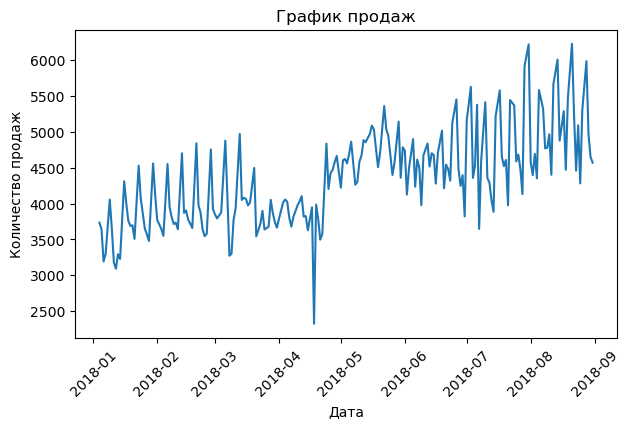

In [19]:
plt.figure(figsize = (7,4))
plt.plot(grouped_df['Дата'],grouped_df['Количество продаж'])
plt.title('График продаж')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.xticks(rotation = 45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [20]:
# График отражает изменение количества продаж за период с января по сентябрь 2018 года. Линия имеет волнообразный характер, но в целом восходящий тренд.
# Минимальная продажа ниже 2500, но похожа на выброс. Также есть несколько выбросов свыше 6000. Продажи несколько нестабильны, но нестабильны постоянно.
# Изменения похоже зависят от дня недели.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [21]:
df.loc[[df['Количество'].idxmax()]]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [22]:
filtered = df[(df['Дата'].dt.weekday ==2) & (df['Дата'].dt.month.isin([6,7,8]))]
print(filtered)

             Дата  Склад   Контрагент Номенклатура  Количество
190523 2018-06-06      1    address_0    product_0          18
190524 2018-06-06      1    address_0    product_1          24
190525 2018-06-06      1    address_0    product_2          19
190526 2018-06-06      1    address_0    product_3           8
190527 2018-06-06      1    address_0    product_4           2
...           ...    ...          ...          ...         ...
298539 2018-08-29      5  address_174   product_23           1
298540 2018-08-29      5  address_174   product_11           2
298541 2018-08-29      5  address_174   product_22           3
298542 2018-08-29      5  address_174   product_15           2
298543 2018-08-29      5  address_174   product_17           1

[18705 rows x 5 columns]


In [23]:
grouped = (filtered.groupby(['Номенклатура'])['Количество'].sum().reset_index())
print(grouped)

   Номенклатура  Количество
0     product_0        7856
1     product_1       12476
2    product_10         663
3    product_11         550
4    product_12         471
5    product_13        1467
6    product_14         440
7    product_15        1490
8    product_16         158
9    product_17        1196
10   product_18         785
11   product_19         640
12    product_2       11584
13   product_20         339
14   product_21         334
15   product_22        2207
16   product_23         444
17    product_3        6311
18    product_4        3263
19    product_5        3001
20    product_6        3209
21    product_7         472
22    product_8         464


In [24]:
top = grouped.sort_values('Количество',ascending = False).head(1)
print(top)                       

  Номенклатура  Количество
1    product_1       12476


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [25]:
weather = pd.read_excel('Погода.xlsx')
    

In [26]:
weather.dtypes

Дата    datetime64[ns]
Т              float64
dtype: object

In [27]:
weather.head

<bound method NDFrame.head of           Дата        Т
0   2018-08-31  11.0250
1   2018-08-30  14.1750
2   2018-08-29  13.8250
3   2018-08-28  14.1125
4   2018-08-27  12.5250
..         ...      ...
235 2018-01-08 -15.4125
236 2018-01-07 -12.7500
237 2018-01-06 -13.3000
238 2018-01-05 -16.8625
239 2018-01-04 -14.0750

[240 rows x 2 columns]>

In [28]:
weather['Дата'] = pd.to_datetime(weather['Дата'],errors = 'coerce',dayfirst = True)

In [29]:
final_df = grouped_df.merge(weather, on = 'Дата', how = 'left')

In [30]:
final_df.head()

,Дата,Количество продаж,Т
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


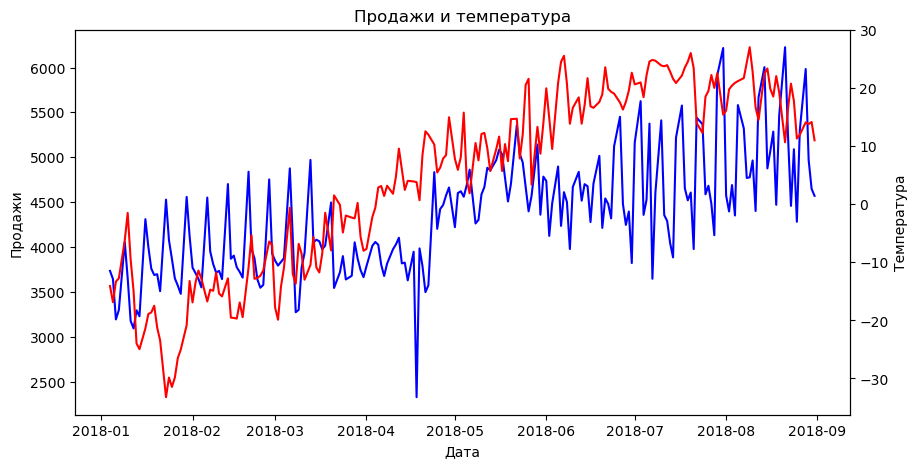

In [46]:
fig,ax1 = plt.subplots(figsize = (10,5))
ax1.plot(final_df['Дата'],final_df['Количество продаж'], color = 'blue', label ='Продажи')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Продажи')

ax2=ax1.twinx()
ax2.plot(final_df['Дата'],final_df['Т'],color = 'red', label ='Температура')
ax2.set_ylabel('Температура')

plt.title('Продажи и температура')
plt.xticks(rotation = 45)
plt.show()


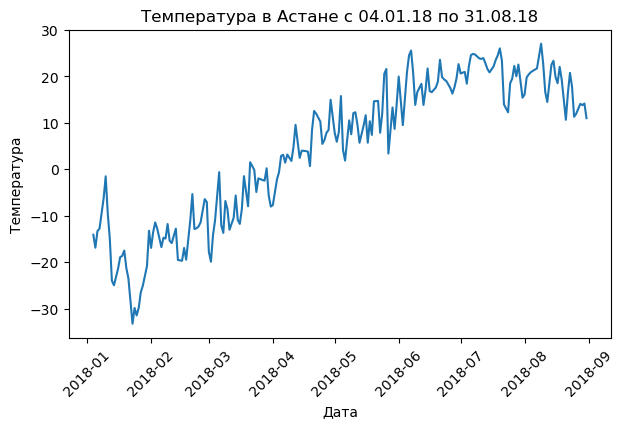

In [32]:
plt.figure(figsize = (7,4))
plt.plot(final_df['Дата'],final_df['Т'])
plt.xlabel('Дата')
plt.ylabel('Температура')
plt.title('Температура в Астане с 0.01.18 по 31.08.18')
plt.xticks(rotation = 45)
plt.show()